# Clinical benchmark of predictions to ClinVar dataset

This workflows compares AlphaMissense, SIFT and PolyPhen-2 predictions using ROC curv and AUC methods.

In [1]:
import re
from pathlib import Path

import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import pandas as pd

Prepare ClinVar dataset

In [2]:
RAW_DATA_DIR = Path.cwd() / "data" / "clinvar"
RES_DIR = Path.cwd() / "results" / "clinvar_benchmark"
RES_DIR.mkdir(parents=True, exist_ok=True)

frames = []
for file_path in sorted(RAW_DATA_DIR.glob("*.tsv")):
    match = re.search(r"glut(\d+)", file_path.stem, flags=re.IGNORECASE)
    if not match:
        continue

    df = pd.read_csv(file_path, sep="\t")
    df.insert(0, "Protein", f"GLUT{match.group(1)}")
    frames.append(df)

merged = pd.concat(frames, ignore_index=True)
merged = merged[["Protein", "Protein change", "Classification"]]
merged = merged.drop_duplicates(subset=["Protein", "Protein change"], keep="first")

merged.head()

,Protein,Protein change,Classification
0,GLUT1,P485L,G: Pathogenic/Likely pathogenic
1,GLUT1,R458W,G: Pathogenic/Likely pathogenic
2,GLUT1,F422L,G: Pathogenic
3,GLUT1,M420T,G: Pathogenic/Likely pathogenic
4,GLUT1,M420V,G: Pathogenic


In [3]:
merged["Classification"] = merged["Classification"].str.removeprefix("G: ")
merged["Position"] = merged["Protein change"].str.extract(r"(\d+)").astype(int)
merged["Class_num"] = merged["Classification"].str.contains("Patho").astype(float)
merged.head()

,Protein,Protein change,Classification,Position,Class_num
0,GLUT1,P485L,Pathogenic/Likely pathogenic,485,1.0
1,GLUT1,R458W,Pathogenic/Likely pathogenic,458,1.0
2,GLUT1,F422L,Pathogenic,422,1.0
3,GLUT1,M420T,Pathogenic/Likely pathogenic,420,1.0
4,GLUT1,M420V,Pathogenic,420,1.0


Add average pathogenicity predictions of same amino acids to the dataset

In [4]:
proteins = {
    'GLUT1':'P11166',
    'GLUT2':'P11168',
    'GLUT3':'P11169',
    'GLUT4':'P14672',
    'GLUT5':'P22732',
    'GLUT6':'Q9UGQ3',
    'GLUT7':'Q6PXP3',
    'GLUT8':'Q9NY64',
    'GLUT9':'Q9NRM0',
    'GLUT10':'O95528',
    'GLUT11':'Q9BYW1',
    'GLUT12':'Q8TD20',
    'GLUT13':'Q96QE2',
    'GLUT14':'Q8TDB8' 
    }

preds = {'alphamissense':'AlphaMissense', 'sift':'SIFT', 'rhapsody':'PolyPhen-2'}
pred_dir = Path.cwd() / 'results/pathogenicities'

for pred in preds.keys():
    for prot in proteins.keys():
        prediction = pd.read_csv(pred_dir / pred / f'all_{proteins[prot]}.csv')
        prediction['residue_label'] = prediction['residue_label'].astype(int)
        prediction['pathogenicity'] = prediction['pathogenicity'].astype(float)

        glut_merged = merged[merged["Protein"] == prot].copy()
        glut_merged[preds[pred]] = glut_merged["Position"].map(
            prediction.set_index("residue_label")["pathogenicity"]
        )

        merged.loc[glut_merged.index, preds[pred]] = glut_merged[preds[pred]]

merged.head()


,Protein,Protein change,Classification,Position,Class_num,AlphaMissense,SIFT,PolyPhen-2
0,GLUT1,P485L,Pathogenic/Likely pathogenic,485,1.0,0.15,0.388947,0.035
1,GLUT1,R458W,Pathogenic/Likely pathogenic,458,1.0,0.66,0.051579,0.957
2,GLUT1,F422L,Pathogenic,422,1.0,0.93,0.000000,0.998
3,GLUT1,M420T,Pathogenic/Likely pathogenic,420,1.0,0.71,0.062632,0.782
4,GLUT1,M420V,Pathogenic,420,1.0,0.71,0.062632,0.782


## compute ROC and AUC

In [5]:
#we need to invert SIFT pathogenicties as it used reversed scale
merged['SIFT '] = 1 - merged['SIFT']
prediction_columns = ['AlphaMissense', 'PolyPhen-2', 'SIFT ']
ground_truth = 'Class_num'

In [6]:
results = []

# correlation and MSE and R2
for method in prediction_columns:
    mse = mean_squared_error(merged[ground_truth], merged[method])
    r2 = r2_score(merged[ground_truth], merged[method])
    corr = merged[ground_truth].corr(merged[method])


    results.append({
        "Method": method,
        "MSE": mse,
        "R2": r2,
        "Correlation": corr,
        })

In [7]:
results = pd.DataFrame(results)
print(results)

          Method       MSE        R2  Correlation
0  AlphaMissense  0.112835  0.451158     0.682597
1     PolyPhen-2  0.145860  0.290521     0.563896
2          SIFT   0.221282 -0.076344     0.463824


set color scale

In [8]:
colors = {
    "AlphaMissense": "#7B3294",  # purple
    "PolyPhen-2": "#66C2A5",     # light green
    "SIFT ": "#FDE725"   # yellow
}

AlphaMissense: ROC-AUC: 0.9115
PolyPhen-2: ROC-AUC: 0.8321
SIFT : ROC-AUC: 0.8326


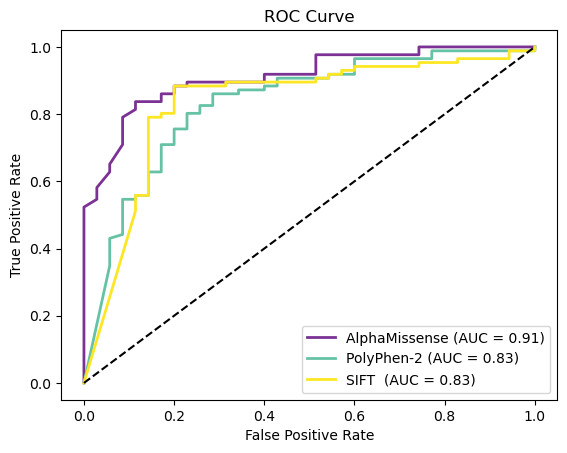

In [9]:

# conversion Class_num to binary (0 = 0.5/0, 1 = Pathogenic)
merged['Class_binary'] = merged[ground_truth].apply(lambda x: 1 if x > 0.5 else 0)

for method in prediction_columns:
    try:
        auc = roc_auc_score(merged['Class_binary'], merged[method])
        print(f"{method}: ROC-AUC: {auc:.4f}")
        
        # Plot ROC curve
        fpr, tpr, thresholds = roc_curve(merged['Class_binary'], merged[method])
        plt.plot(fpr, tpr, color=colors.get(method, None), lw=2, label=f'{method} (AUC = {auc:.2f})')
    except ValueError:
        pass


plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig(RES_DIR / 'ROC_curve.tiff', dpi=300, bbox_inches='tight')

plt.show()